<a href="https://colab.research.google.com/github/Ecesu893/Tasarim2/blob/main/compare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os, zipfile
from google.colab import files

print("✅ Kütüphaneler yüklendi.")

✅ Kütüphaneler yüklendi.


In [ ]:
json_files = {
    'ResNet18 [NoAug]'      : '/content/results_resnet18_noaug.json',
    'ResNet18 [Aug]'        : '/content/results_resnet18_aug.json',
    'EfficientNet [NoAug]'  : '/content/results_efficientnet_noaug.json',
    'EfficientNet [Aug]'    : '/content/results_efficientnet_aug.json',
}

all_results = {}
for label, path in json_files.items():
    if os.path.exists(path):
        with open(path, 'r') as f:
            all_results[label] = json.load(f)
        print(f"  ✅ {label:<25} yüklendi")
    else:
        print(f"  ❌ {label:<25} BULUNAMADI — {path}")

CLASS_NAMES = list(all_results.values())[0]['class_names']
print(f"\n📂 Sınıflar: {CLASS_NAMES}")

  ✅ ResNet18 [NoAug]          yüklendi
  ✅ ResNet18 [Aug]            yüklendi
  ✅ EfficientNet [NoAug]      yüklendi
  ✅ EfficientNet [Aug]        yüklendi

📂 Sınıflar: ['Disease-Downy', 'Disease-Powdery', 'Healthy', 'Insect-Pest']


In [ ]:
summary = []
for label, res in all_results.items():
    summary.append({
        'Model'    : label,
        'Accuracy' : f"{res['accuracy']*100:.2f}%",
        'Precision': f"{res['precision']*100:.2f}%",
        'Recall'   : f"{res['recall']*100:.2f}%",
        'F1-Score' : f"{res['f1']*100:.2f}%",
    })

df = pd.DataFrame(summary)
print("\n" + "="*70)
print("📊 ÖZET KARŞILAŞTIRMA TABLOSU")
print("="*70)
print(df.to_string(index=False))
print("="*70)


📊 ÖZET KARŞILAŞTIRMA TABLOSU
               Model Accuracy Precision Recall F1-Score
    ResNet18 [NoAug]   73.97%    72.62% 73.97%   72.31%
      ResNet18 [Aug]   92.74%    92.90% 92.74%   92.63%
EfficientNet [NoAug]   73.65%    72.38% 73.65%   72.65%
  EfficientNet [Aug]   96.21%    96.25% 96.21%   96.19%


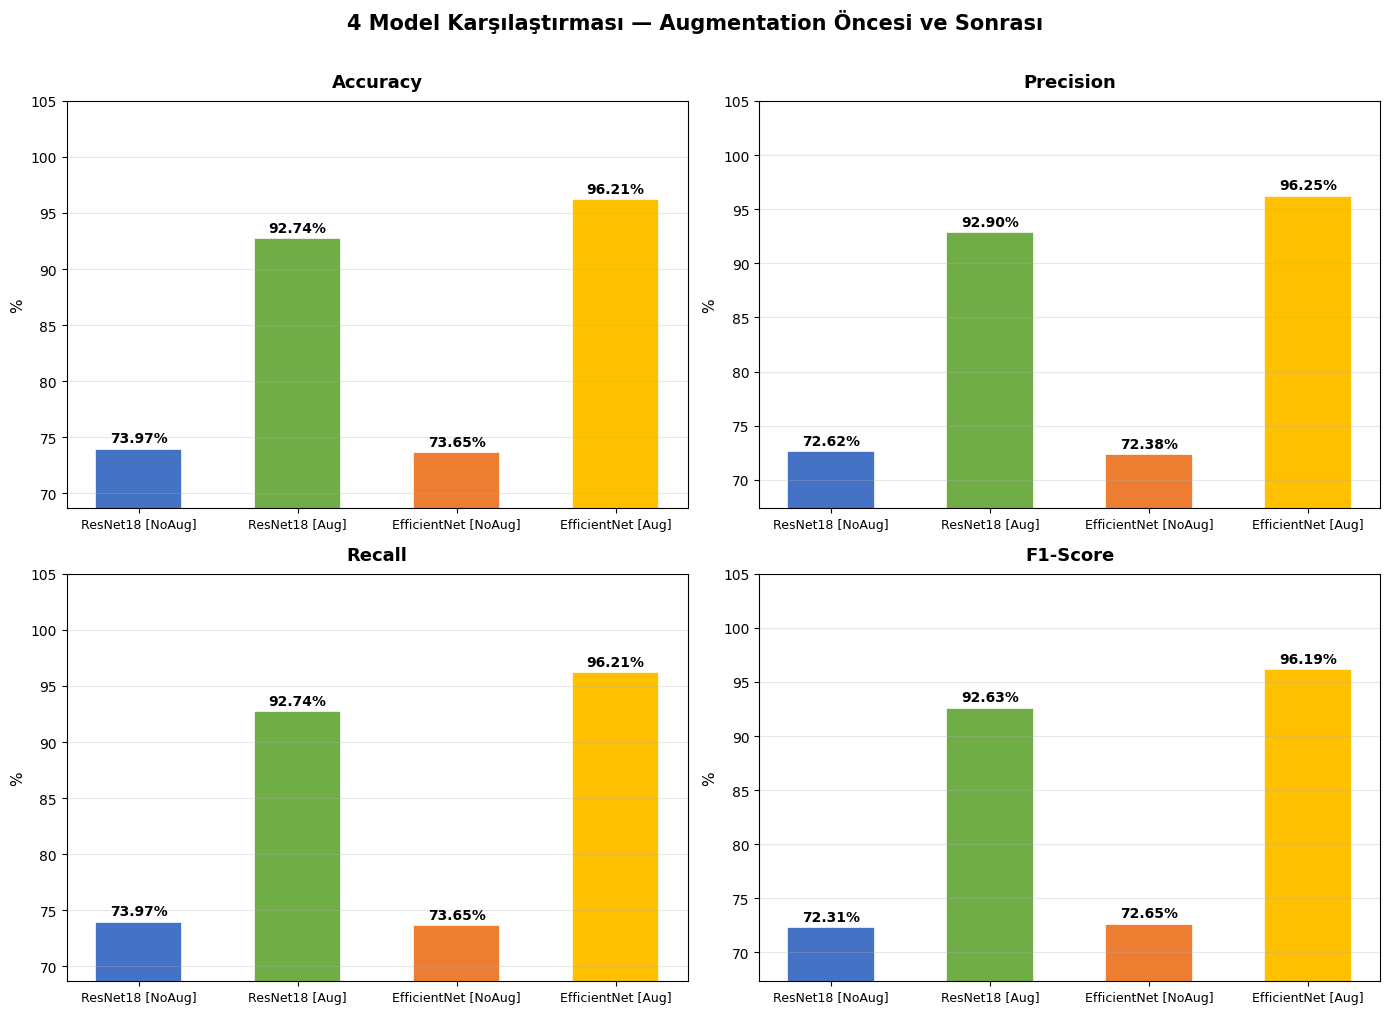

💾 final_barchart.png kaydedildi.


In [ ]:
metrics  = ['accuracy', 'precision', 'recall', 'f1']
labels   = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
m_labels = list(all_results.keys())
colors   = ['#4472C4', '#70AD47', '#ED7D31', '#FFC000']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, metric, label in zip(axes, metrics, labels):
    values = [all_results[m][metric] * 100 for m in all_results]
    bars   = ax.bar(m_labels, values, color=colors,
                    edgecolor='white', linewidth=1.2, width=0.55)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                f'{val:.2f}%', ha='center', va='bottom',
                fontsize=10, weight='bold')
    ax.set_title(label, fontsize=13, weight='bold', pad=10)
    ax.set_ylabel('%', fontsize=11)
    ax.set_ylim(max(0, min(values) - 5), 105)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', labelsize=9)

plt.suptitle('4 Model Karşılaştırması — Augmentation Öncesi ve Sonrası',
             fontsize=15, weight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/final_barchart.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 final_barchart.png kaydedildi.")

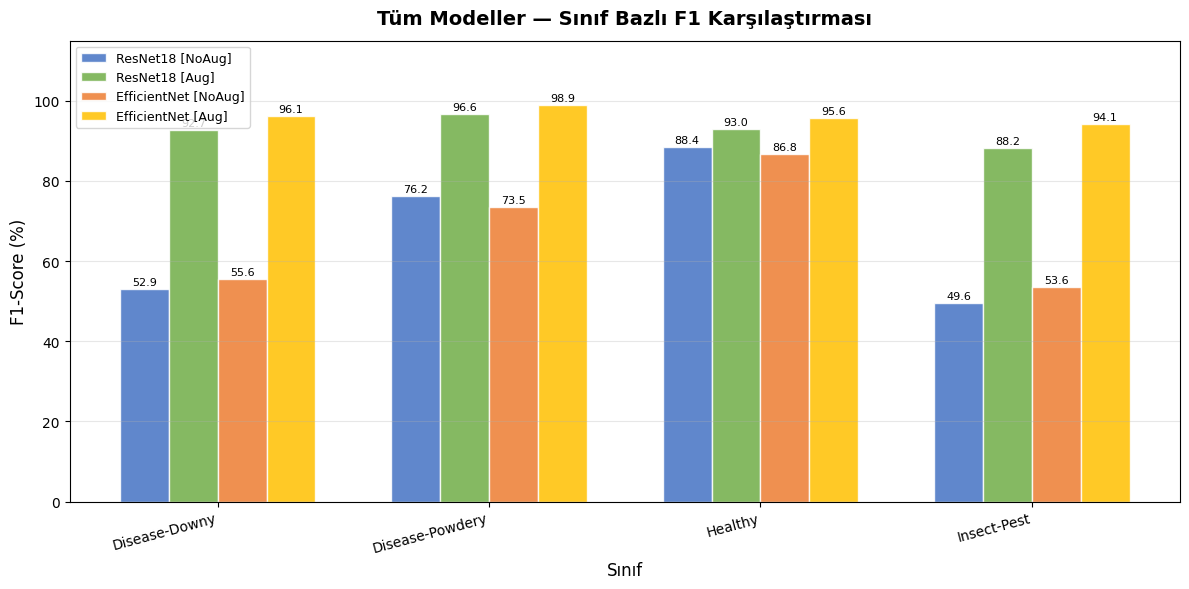

💾 final_per_class_f1.png kaydedildi.


In [ ]:
n_models = len(all_results)
x        = np.arange(len(CLASS_NAMES))
width    = 0.18
colors   = ['#4472C4', '#70AD47', '#ED7D31', '#FFC000']

fig, ax = plt.subplots(figsize=(12, 6))
for i, (mname, res) in enumerate(all_results.items()):
    f1_vals = np.array(res['f1_per_class']) * 100
    offset  = (i - (n_models - 1) / 2) * width
    bars    = ax.bar(x + offset, f1_vals, width,
                     label=mname, color=colors[i], alpha=0.85, edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.5,
                f'{h:.1f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Sınıf', fontsize=12)
ax.set_ylabel('F1-Score (%)', fontsize=12)
ax.set_title('Tüm Modeller — Sınıf Bazlı F1 Karşılaştırması',
             fontsize=14, weight='bold', pad=12)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=15, ha='right', fontsize=10)
ax.legend(fontsize=9)
ax.set_ylim(0, 115)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/final_per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 final_per_class_f1.png kaydedildi.")

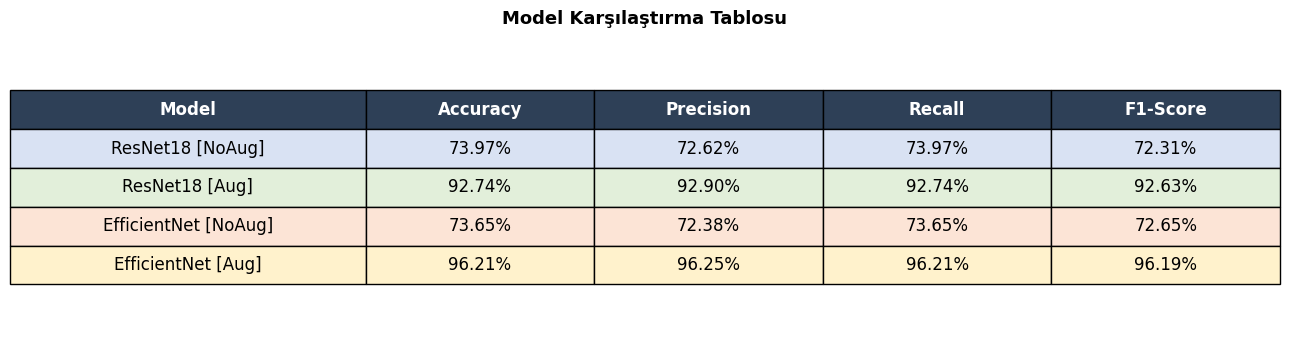

💾 final_table.png kaydedildi.


In [ ]:
fig2, ax2 = plt.subplots(figsize=(13, 3.5))
ax2.axis('off')

col_labels = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
rows = [[r['Model'], r['Accuracy'], r['Precision'],
         r['Recall'], r['F1-Score']] for r in summary]

tbl = ax2.table(cellText=rows, colLabels=col_labels,
                cellLoc='center', loc='center',
                colWidths=[0.28, 0.18, 0.18, 0.18, 0.18])
tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.scale(1, 2.2)

for j in range(len(col_labels)):
    tbl[(0, j)].set_facecolor('#2E4057')
    tbl[(0, j)].set_text_props(weight='bold', color='white')

row_colors = ['#D9E2F3', '#E2EFDA', '#FCE4D6', '#FFF2CC']
for i in range(1, 5):
    for j in range(len(col_labels)):
        tbl[(i, j)].set_facecolor(row_colors[i - 1])

plt.title('Model Karşılaştırma Tablosu',
          fontsize=13, weight='bold', pad=15)
plt.tight_layout()
plt.savefig('/content/final_table.png', dpi=200, bbox_inches='tight')
plt.show()
print("💾 final_table.png kaydedildi.")


📈 AUGMENTATION ETKİSİ

  ResNet18:
    ACCURACY  : 73.97% → 92.74%  (▲ +18.78%)
    PRECISION : 72.62% → 92.90%  (▲ +20.27%)
    RECALL    : 73.97% → 92.74%  (▲ +18.78%)
    F1        : 72.31% → 92.63%  (▲ +20.31%)

  EfficientNet-B0:
    ACCURACY  : 73.65% → 96.21%  (▲ +22.56%)
    PRECISION : 72.38% → 96.25%  (▲ +23.87%)
    RECALL    : 73.65% → 96.21%  (▲ +22.56%)
    F1        : 72.65% → 96.19%  (▲ +23.55%)



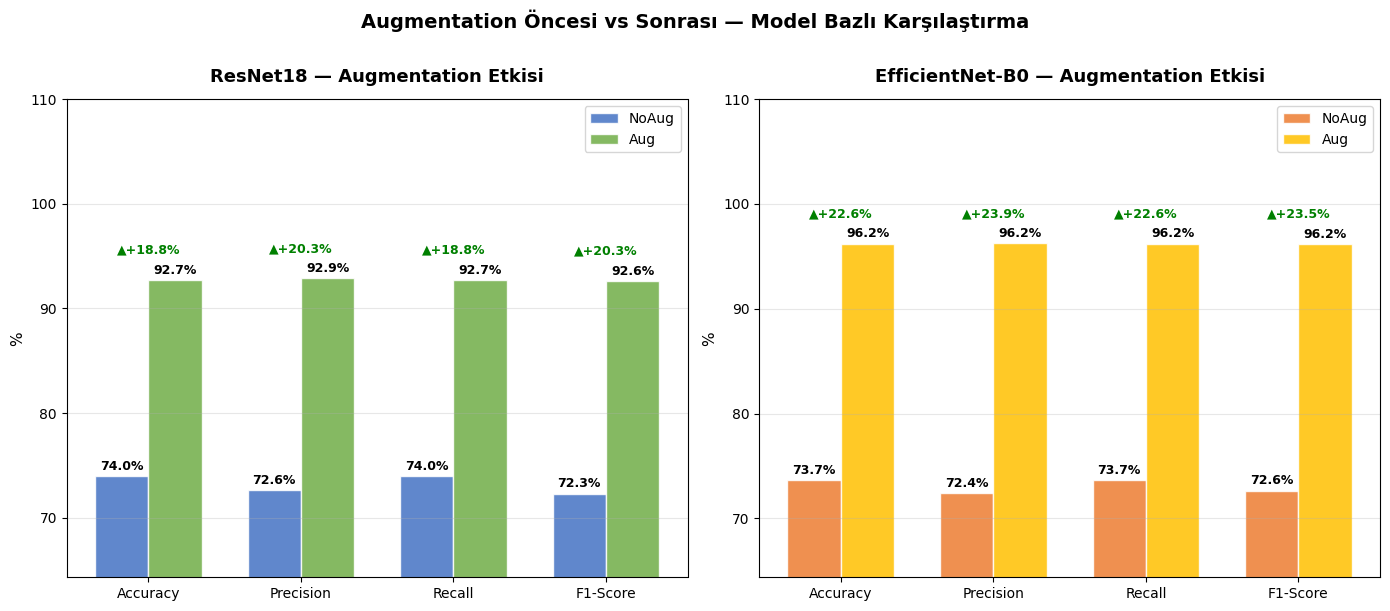

💾 final_augmentation_effect.png kaydedildi.


In [ ]:
print("\n" + "="*60)
print("📈 AUGMENTATION ETKİSİ")
print("="*60)

pairs = [
    ('ResNet18 [NoAug]',     'ResNet18 [Aug]',     'ResNet18'),
    ('EfficientNet [NoAug]', 'EfficientNet [Aug]', 'EfficientNet-B0'),
]

for mbase, maug, mname in pairs:
    print(f"\n  {mname}:")
    for metric in ['accuracy', 'precision', 'recall', 'f1']:
        base_val = all_results[mbase][metric] * 100
        aug_val  = all_results[maug][metric]  * 100
        diff     = aug_val - base_val
        arrow    = "▲" if diff > 0 else "▼"
        sign     = "+" if diff > 0 else ""
        print(f"    {metric.upper():<10}: "
              f"{base_val:.2f}% → {aug_val:.2f}%  "
              f"({arrow} {sign}{diff:.2f}%)")

print("\n" + "="*60)

# ── Görsel ────────────────────────────────────────────────────
metrics      = ['accuracy', 'precision', 'recall', 'f1']
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
models       = ['ResNet18', 'EfficientNet-B0']
noaug_keys   = ['ResNet18 [NoAug]', 'EfficientNet [NoAug]']
aug_keys     = ['ResNet18 [Aug]',   'EfficientNet [Aug]']
colors_noaug = ['#4472C4', '#ED7D31']
colors_aug   = ['#70AD47', '#FFC000']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax_idx, (mname, noaug_key, aug_key, c_noaug, c_aug) in enumerate(
        zip(models, noaug_keys, aug_keys, colors_noaug, colors_aug)):

    noaug_vals = [all_results[noaug_key][m] * 100 for m in metrics]
    aug_vals   = [all_results[aug_key][m]   * 100 for m in metrics]
    diffs      = [a - b for a, b in zip(aug_vals, noaug_vals)]

    x     = np.arange(len(metrics))
    width = 0.35
    ax    = axes[ax_idx]

    bars1 = ax.bar(x - width/2, noaug_vals, width, label='NoAug',
                   color=c_noaug, alpha=0.85, edgecolor='white')
    bars2 = ax.bar(x + width/2, aug_vals,   width, label='Aug',
                   color=c_aug,   alpha=0.85, edgecolor='white')

    # Değerleri yaz
    for bar, val in zip(bars1, noaug_vals):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9, weight='bold')
    for bar, val in zip(bars2, aug_vals):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9, weight='bold')

    # Fark okları
    for i, (b1, b2, diff) in enumerate(zip(bars1, bars2, diffs)):
        arrow = "▲" if diff > 0 else "▼"
        color = 'green' if diff > 0 else 'red'
        sign  = "+" if diff > 0 else ""
        ax.text(i, max(noaug_vals[i], aug_vals[i]) + 2.5,
                f'{arrow}{sign}{diff:.1f}%',
                ha='center', fontsize=9, color=color, weight='bold')

    ax.set_title(f'{mname} — Augmentation Etkisi',
                 fontsize=13, weight='bold', pad=12)
    ax.set_ylabel('%', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(metric_names, fontsize=10)
    ax.set_ylim(max(0, min(noaug_vals + aug_vals) - 8), 110)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Augmentation Öncesi vs Sonrası — Model Bazlı Karşılaştırma',
             fontsize=14, weight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/final_augmentation_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 final_augmentation_effect.png kaydedildi.")


🏆 METRİK BAZLI KAZANANLAR
  Accuracy    : 🥇 EfficientNet [Aug]        (96.21%)
  Precision   : 🥇 EfficientNet [Aug]        (96.25%)
  Recall      : 🥇 EfficientNet [Aug]        (96.21%)
  F1-Score    : 🥇 EfficientNet [Aug]        (96.19%)

🏆 GENEL KAZANAN: EfficientNet [Aug]


/tmp/ipykernel_4164/3918834507.py:75: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4164/3918834507.py:76: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/final_winner_table.png', dpi=200, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


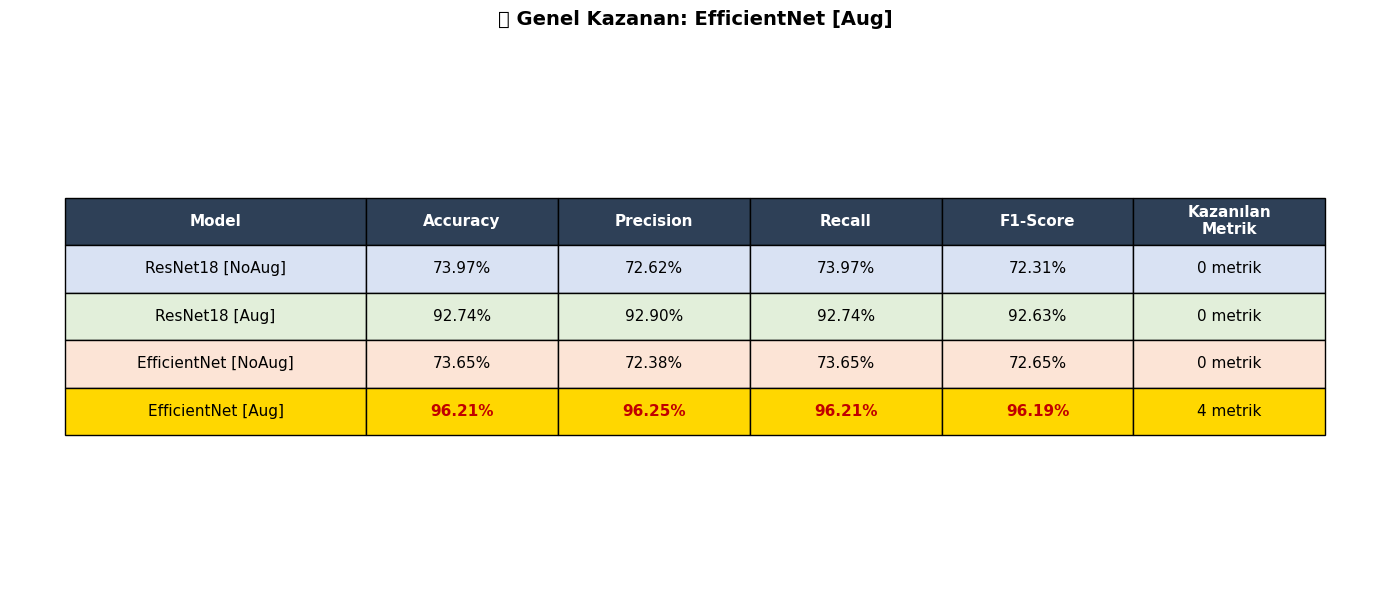

/tmp/ipykernel_4164/3918834507.py:111: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4164/3918834507.py:112: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/final_winner_barchart.png', dpi=150, bbox_inches='tight')


💾 final_winner_table.png kaydedildi.


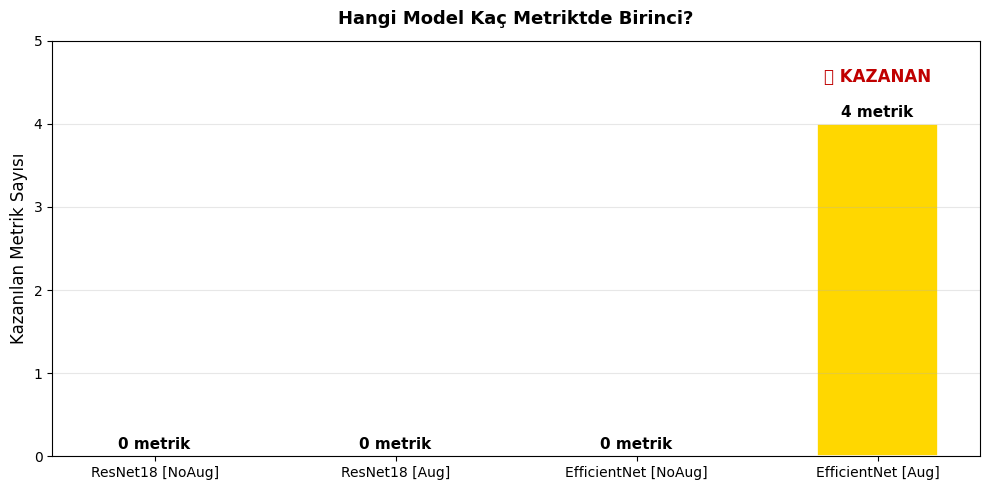

💾 final_winner_barchart.png kaydedildi.


In [ ]:
# ── Kazanan Analizi ───────────────────────────────────────────
metrics      = ['accuracy', 'precision', 'recall', 'f1']
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Her metrikte kazananı bul
print("\n" + "="*60)
print("🏆 METRİK BAZLI KAZANANLAR")
print("="*60)

metric_winners = {}
for metric, mname in zip(metrics, metric_names):
    best_model = max(all_results, key=lambda m: all_results[m][metric])
    best_val   = all_results[best_model][metric] * 100
    metric_winners[mname] = best_model
    print(f"  {mname:<12}: 🥇 {best_model:<25} ({best_val:.2f}%)")

# Genel kazanan — en çok metrikte birinci olan
from collections import Counter
win_counts = Counter(metric_winners.values())
overall_winner = win_counts.most_common(1)[0][0]
print(f"\n🏆 GENEL KAZANAN: {overall_winner}")
print("="*60)

# ── Görsel Kazanan Tablosu ────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')

col_labels = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Kazanılan\nMetrik']

rows = []
win_count_per_model = Counter(metric_winners.values())

for mname, res in all_results.items():
    wins = win_count_per_model.get(mname, 0)
    trophy = "🥇" * wins if wins > 0 else "—"
    rows.append([
        mname,
        f"{res['accuracy']*100:.2f}%",
        f"{res['precision']*100:.2f}%",
        f"{res['recall']*100:.2f}%",
        f"{res['f1']*100:.2f}%",
        f"{wins} metrik"
    ])

tbl = ax.table(cellText=rows, colLabels=col_labels,
               cellLoc='center', loc='center',
               colWidths=[0.22, 0.14, 0.14, 0.14, 0.14, 0.14])
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 2.5)

# Header
for j in range(len(col_labels)):
    tbl[(0, j)].set_facecolor('#2E4057')
    tbl[(0, j)].set_text_props(weight='bold', color='white')

# Satır renkleri — kazanan modeli vurgula
row_colors = ['#D9E2F3', '#E2EFDA', '#FCE4D6', '#FFF2CC']
for i, (mname, res) in enumerate(all_results.items()):
    for j in range(len(col_labels)):
        if mname == overall_winner:
            tbl[(i+1, j)].set_facecolor('#FFD700')  # Altın rengi — kazanan
        else:
            tbl[(i+1, j)].set_facecolor(row_colors[i])

# Metrik sütunlarında en yüksek değeri koyu yap
for m_idx, metric in enumerate(metrics):
    best_val = max(all_results[m][metric] for m in all_results)
    for i, (mname, res) in enumerate(all_results.items()):
        if abs(res[metric] - best_val) < 0.0001:
            tbl[(i+1, m_idx+1)].set_text_props(weight='bold', color='#C00000')

plt.title(f'🏆 Genel Kazanan: {overall_winner}',
          fontsize=14, weight='bold', pad=20)
plt.tight_layout()
plt.savefig('/content/final_winner_table.png', dpi=200, bbox_inches='tight')
plt.show()
print("💾 final_winner_table.png kaydedildi.")

# ── Kazanan Bar Chart ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

model_names = list(all_results.keys())
win_counts_list = [win_count_per_model.get(m, 0) for m in model_names]
colors = ['#FFD700' if m == overall_winner else '#B0B0B0' for m in model_names]

bars = ax.bar(model_names, win_counts_list, color=colors,
              edgecolor='white', linewidth=1.2, width=0.5)

for bar, val in zip(bars, win_counts_list):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
            f'{val} metrik', ha='center', va='bottom',
            fontsize=11, weight='bold')

ax.set_ylabel('Kazanılan Metrik Sayısı', fontsize=12)
ax.set_title('Hangi Model Kaç Metriktde Birinci?',
             fontsize=13, weight='bold', pad=12)
ax.set_ylim(0, len(metrics) + 1)
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', labelsize=10)

# Kazananı vurgula
ax.annotate(f'🏆 KAZANAN',
            xy=(model_names.index(overall_winner),
                win_count_per_model[overall_winner]),
            xytext=(model_names.index(overall_winner),
                    win_count_per_model[overall_winner] + 0.5),
            fontsize=12, color='#C00000', weight='bold',
            ha='center')

plt.tight_layout()
plt.savefig('/content/final_winner_barchart.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 final_winner_barchart.png kaydedildi.")

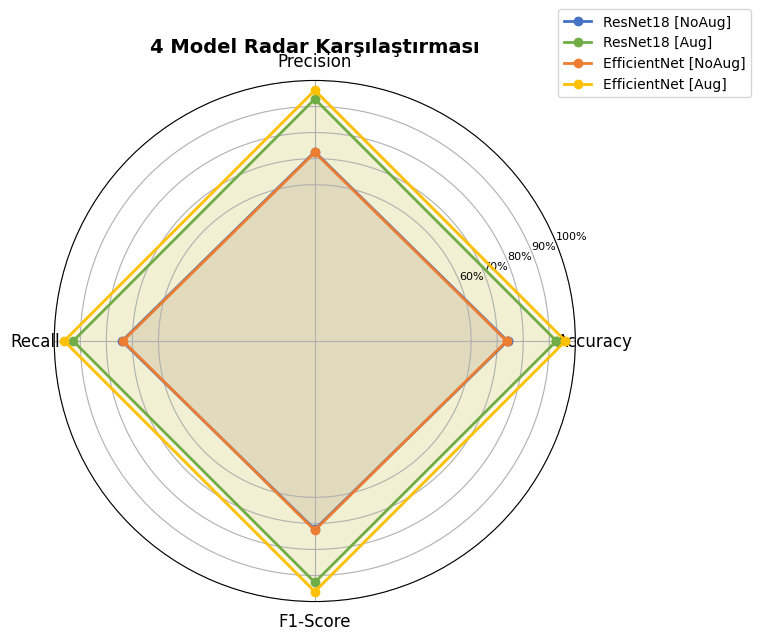

💾 final_radar.png kaydedildi.


In [ ]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = ['#4472C4', '#70AD47', '#ED7D31', '#FFC000']

for i, (mname, res) in enumerate(all_results.items()):
    values = [res['accuracy']*100, res['precision']*100,
              res['recall']*100, res['f1']*100]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2,
            color=colors[i], label=mname)
    ax.fill(angles, values, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 100)
ax.set_yticks([60, 70, 80, 90, 100])
ax.set_yticklabels(['60%', '70%', '80%', '90%', '100%'], fontsize=8)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
ax.set_title('4 Model Radar Karşılaştırması',
             fontsize=14, weight='bold', pad=20)

plt.tight_layout()
plt.savefig('/content/final_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 final_radar.png kaydedildi.")

In [ ]:
zip_path = '/content/notebook5_karsilastirma.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in ['/content/final_barchart.png',
              '/content/final_per_class_f1.png',
              '/content/final_table.png',
              '/content/final_augmentation_effect.png',
              '/content/final_winner_table.png',
              '/content/final_winner_barchart.png',
              '/content/final_radar.png']:
        if os.path.exists(f):
            zf.write(f, os.path.basename(f))
            print(f"  ✅ Eklendi: {os.path.basename(f)}")

files.download(zip_path)
print("\n✅ notebook5_karsilastirma.zip indirildi!")

  ✅ Eklendi: final_barchart.png
  ✅ Eklendi: final_per_class_f1.png
  ✅ Eklendi: final_table.png
  ✅ Eklendi: final_augmentation_effect.png
  ✅ Eklendi: final_winner_table.png
  ✅ Eklendi: final_winner_barchart.png
  ✅ Eklendi: final_radar.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ notebook5_karsilastirma.zip indirildi!
